# Lecture 09 Demos 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Demo 1: DT complex exponential signals

In [5]:
max_n = 100
n_vals = np.arange(max_n)
cos_3n = np.cos(3 * n_vals)

Text(0, 0.5, 'x[n] = cos(3n)')

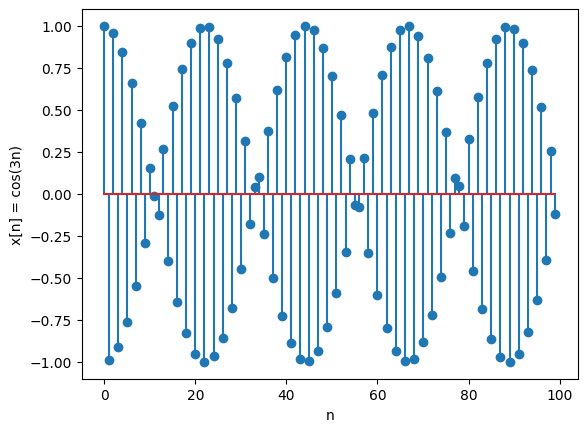

In [6]:
plt.stem(n_vals, cos_3n)
plt.xlabel("n")
plt.ylabel("x[n] = cos(3n)")

## Demo 2: Fourier series of a DT square wave

In [7]:
x = np.array([1, 1, 1, 0, 0, 0])
ck = np.array([0.5, (1 - np.sqrt(3)*1j)/6, 0, 1/6, 0, (1 + np.sqrt(3)*1j)/6])

In [43]:
x_from_ck = np.array([
    np.sum([ck[k] * np.exp(2*np.pi*1j*k*n/6) for k in range(6)]).real 
    for n in range(6)
])

<StemContainer object of 3 artists>

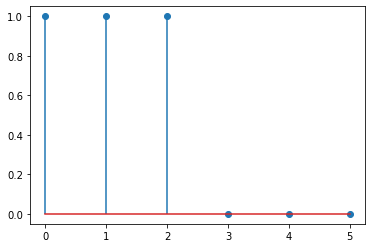

In [44]:
plt.stem(x)

<StemContainer object of 3 artists>

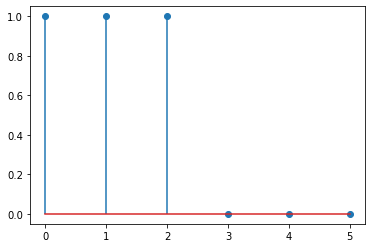

In [45]:
plt.stem(x_from_ck)

Shift the square wave left by one, then speed it up by a factor of two:

<StemContainer object of 3 artists>

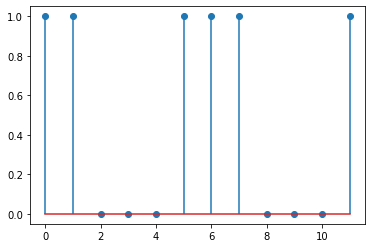

In [46]:
x_shifted = np.array([1, 1, 0, 0, 0, 1])
plt.stem(np.concatenate((x_shifted, x_shifted)))

<StemContainer object of 3 artists>

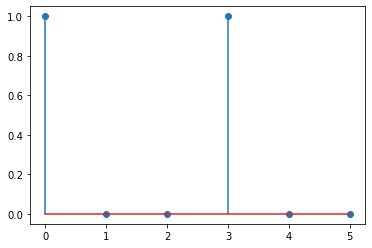

In [47]:
x_shifted_scaled = np.array([x_shifted[(2 * n) % 6] for n in range(6)])
plt.stem(x_shifted_scaled)

<StemContainer object of 3 artists>

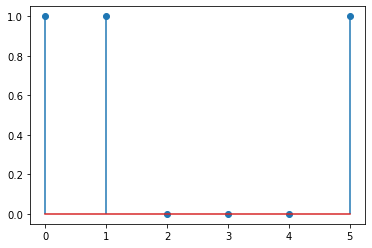

In [49]:
shift = -1
ck_shifted = [np.exp(-1j*2*np.pi*k*shift/6) * ck[k] for k in range(6)]

x_from_ck_shifted = np.array([
    np.sum([ck_shifted[k] * np.exp(2*np.pi*1j*k*n/6) for k in range(6)]).real 
    for n in range(6)
])

plt.stem(x_from_ck_shifted)

<StemContainer object of 3 artists>

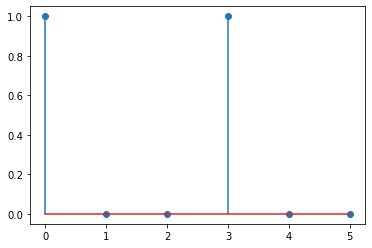

In [50]:
shift = -1
ck_shifted_scaled = [2 * np.exp(-1j*2*np.pi*k*shift/6) * ck[k] for k in range(6)]

x_from_ck_shifted = np.array([
    np.sum([ck_shifted[k] * np.exp(2*np.pi*1j*k*n/3) for k in range(6)]).real 
    for n in range(6)
])

plt.stem(x_from_ck_shifted)

## Demo 3: Frequency response of moving average filter

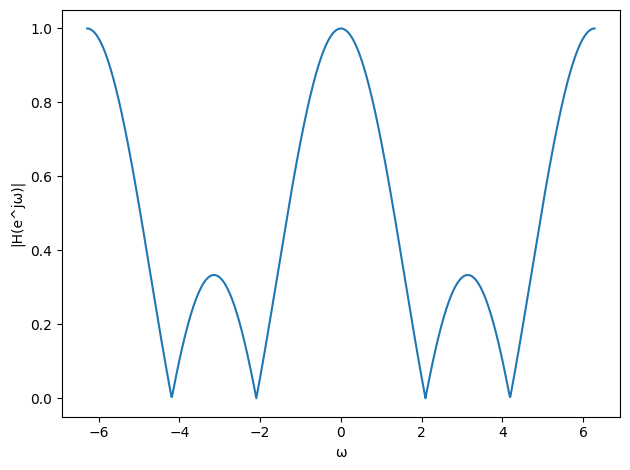

In [9]:
def frequency_response(ω, M):
    return np.sum([np.exp(-1j * ω * k) for k in range(-M, M+1)]) / (2 * M + 1)

M = 1
ω_range = np.linspace(-2*np.pi, 2*np.pi, 1000)
h_jω = np.array([frequency_response(ω, M) for ω in ω_range])

plt.plot(ω_range, np.abs(h_jω))
plt.xlabel("ω")
plt.ylabel("|H(e^jω)|")
plt.tight_layout()